<a href="https://colab.research.google.com/github/Dragan-Al/ml-product-reviews-project/blob/main/notebooks/product_reviews_analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## Loading and inspecting Dataset

In [3]:
import pandas as pd

# load dataset from GitHub

url = "https://raw.githubusercontent.com/Dragan-Al/ml-product-reviews-project/main/data/product_reviews_full.csv"
df = pd.read_csv(url)

# Print Shape (number of rows and columns)
print("Dataset shape (rows, columns):", df.shape)

# Show first 5 rows

print("\nFirst 5 rows")
display(df.head())

# Show column data types and non-null counts
print("\nDataset info:")
df.info()



Dataset shape (rows, columns): (171380, 6)

First 5 rows


,review_uuid,product_name,product_price,review_title,review_text,sentiment
0,31b07b9a-4567-4db1-81f6-1bcef33b3e7b,Candes 12 L Room/Personal Air Cooler??????(Whi...,48.18,Super!,great cooler excellent air flow and for this p...,positive
1,1cb2b4b5-9805-4c2d-9393-6b1382cb7c53,Candes 12 L Room/Personal Air Cooler??????(Whi...,48.18,Awesome,best budget 2 fit cooler nice cooling,positive
2,f64165f0-29a2-4cfb-8b15-13c0c893e54d,Candes 12 L Room/Personal Air Cooler??????(Whi...,48.18,Fair,the quality is good but the power of air is de...,positive
3,e442e083-a343-4052-b015-41e531e52d3e,Candes 12 L Room/Personal Air Cooler??????(Whi...,48.18,Useless product,very bad product its a only a fan,negative
4,f4abefb8-22f0-4672-af73-2aa2954b24e0,Candes 12 L Room/Personal Air Cooler??????(Whi...,48.18,Fair,ok ok product,Neutral



Dataset info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 171380 entries, 0 to 171379
Data columns (total 6 columns):
 #   Column         Non-Null Count   Dtype 
---  ------         --------------   ----- 
 0   review_uuid    171380 non-null  object
 1   product_name   171380 non-null  object
 2   product_price  170954 non-null  object
 3   review_title   171379 non-null  object
 4   review_text    171379 non-null  object
 5   sentiment      166369 non-null  object
dtypes: object(6)
memory usage: 7.8+ MB


## Count missing values per column


In [4]:
print("Missing calues per Column:")
print(df.isna().sum())

Missing calues per Column:
review_uuid         0
product_name        0
product_price     426
review_title        1
review_text         1
sentiment        5011
dtype: int64


## Visualize missing data with seaborn heatmap

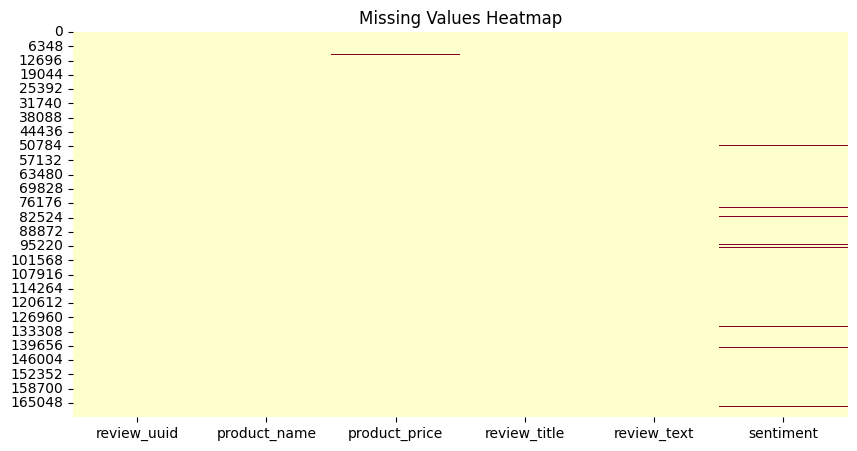

In [5]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 5))
sns.heatmap(df.isna(), cbar=False, cmap="YlOrRd")
plt.title("Missing Values Heatmap")
plt.show()

## Count occurances od each sentiment label


In [6]:
sentiment_counts = df["sentiment"].value_counts()

#print counts

print("Sentiment distribution (counts):")
print(sentiment_counts)

Sentiment distribution (counts):
sentiment
positive    85537
negative    32369
Positive    22361
Negative    12392
neutral     10508
Neutral      3202
Name: count, dtype: int64


## Plot sentiment Distribution

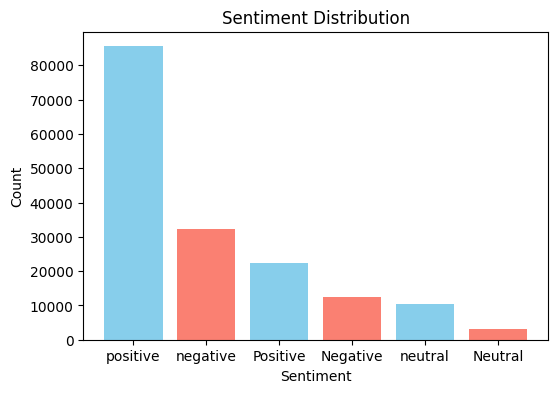

In [7]:
plt.figure(figsize=(6,4))
plt.bar(sentiment_counts.index, sentiment_counts.values, color=["skyblue", "salmon"])
plt.xlabel("Sentiment")
plt.ylabel("Count")
plt.title("Sentiment Distribution")
plt.show()

# Check the 'Product price' column

In [8]:
print("Data type of product_price column:", df["product_price"].dtype)

print("\nFirst 10 values in product_price column")
print(df["product_price"].head(10))

print("\nTop 20 most frequent values in product_price column:")
print(df["product_price"].value_counts().head(20))

problematic_values = ["Free", "Not Availible", "N/A", "None", "-", "free", "Unvailable"]
mask_problematic = df["product_price"].astype(str).str.strip().isin(problematic_values)
df_problematic = df[mask_problematic]

print(f"\nFound {len(df_problematic)} rows with problematic values:")
display(df_problematic[["product_price"]].drop_duplicates())

price_clean = df["product_price"].astype(str).str.strip()
price_numeric = pd.to_numeric(price_clean, errors = "coerce")

invalid_prices = df[price_numeric.isna()]
print("Number of non-numeric prices:", len(invalid_prices))
display(invalid_prices[["product_price"]].drop_duplicates().head(20))


Data type of product_price column: object

First 10 values in product_price column
0    48.18
1    48.18
2    48.18
3    48.18
4    48.18
5    48.18
6    48.18
7    48.18
8    48.18
9    48.18
Name: product_price, dtype: object

Top 20 most frequent values in product_price column:
product_price
2.63        4483
5.41        2648
$5.41       2577
19.27       2575
$2.63       2499
42.16       2242
168.66      2175
8.42        2103
6.01        1857
373.48      1824
3.6         1778
18.06       1710
$19.27      1671
$3.60       1608
96.37       1496
$168.66     1461
3.0         1395
$6.01       1359
3.24        1333
2.4         1321
Name: count, dtype: int64

Found 0 rows with problematic values:


,product_price


Number of non-numeric prices: 68858


,product_price
22,NaN
34279,$6.86
34512,$2.76
34553,$6.95
35245,$4.35
36212,$19.27
36613,$21.67
36622,$7.22
36753,$9.63
36766,$7.82


## Drop all rows with missing values


In [9]:
df = df.dropna()

print("New dataset shape:", df.shape)

print("Missing values per column:")
print(df.isna().sum())

New dataset shape: (165960, 6)
Missing values per column:
review_uuid      0
product_name     0
product_price    0
review_title     0
review_text      0
sentiment        0
dtype: int64


Count the number of rows before and after removin missing values

In [10]:
# Count the number of rows before removing missing values
rows_before = len(df)

# Filter out rows that contain at least one missing value
rows_with_nan = df[df.isnull().any(axis=1)]

# Display a random sample of rows that will be removed
print(" Randomly selected rows containing missing values:\n")
print(rows_with_nan.sample(n=min(5, len(rows_with_nan)), random_state=42))

# Remove rows with any missing values
df_cleaned = df.dropna()

# Count the number of rows after removing missing values
rows_after = len(df_cleaned)

# Show removal statistics
print("\n Removal statistics:")
print(f"- Number of rows before: {rows_before}")
print(f"- Number of rows after: {rows_after}")
print(f"- Number of removed rows: {rows_before - rows_after}")

 Randomly selected rows containing missing values:

Empty DataFrame
Columns: [review_uuid, product_name, product_price, review_title, review_text, sentiment]
Index: []

 Removal statistics:
- Number of rows before: 165960
- Number of rows after: 165960
- Number of removed rows: 0


## parisaranje kolone product-price

## Step 1: Convert to string and remove the 'USD' prefix and any leading/trailing spaces

In [11]:
df['product_price_cleaned'] = (
    df['product_price']
    .astype(str)
    .str.replace(r'$', '', regex=True)    # Remove '$'
    .str.replace(r'[^\d.]', '', regex=True) # Remove all non-numeric characters except the dot
    .str.strip()
)

## Step 2: Convert cleaned string to float

In [12]:
df['product_price'] = pd.to_numeric(df['product_price_cleaned'], errors='coerce')

## Step 3: Drop the temporary column

In [13]:
df = df.drop(columns=['product_price_cleaned'])

## Step 4: Drop any rows where conversion failed (still NaN)

In [14]:
df = df.dropna(subset=['product_price'])

## Step 5: Confirm result

In [15]:
print("Column type after parsing:", df['product_price'].dtype)
print("\nPrice summary:")
print(df['product_price'].describe())

Column type after parsing: float64

Price summary:
count    165960.000000
mean         65.786896
std         135.944167
min           0.180000
25%           4.190000
50%          14.450000
75%          66.250000
max        1566.140000
Name: product_price, dtype: float64


## Standardizacija vrednosti u koloni sentiment

In [16]:
# Step 1: Convert all sentiment values to lowercase and strip extra spaces
df['sentiment'] = df['sentiment'].astype(str).str.lower().str.strip()

# Step 2: Show all unique values in the sentiment column
print("Unique sentiment values after cleaning:")
print(df['sentiment'].value_counts())

# Step 3: Convert column type to 'category'
df['sentiment'] = df['sentiment'].astype('category')
print("\nSentiment column converted to type:", df['sentiment'].dtype)

Unique sentiment values after cleaning:
sentiment
positive    107619
negative     44663
neutral      13678
Name: count, dtype: int64

Sentiment column converted to type: category


## Removing irrelevant columns

In [17]:
df = df.drop(columns=["review_uuid", "product_name"])

# Prewiew remaining columns

print("Remaining colums:")
print(df.columns.tolist())

Remaining colums:
['product_price', 'review_title', 'review_text', 'sentiment']


## Analiza: Raspodela cena po sentimentu

Price summary by sentiment:
              count       mean         std   min   25%    50%     75%      max
sentiment                                                                     
negative    44663.0  59.655028  112.306009  0.71  4.35  18.06  60.710  1566.14
neutral     13678.0  55.532342  107.524238  0.71  3.30  10.23  59.845  1204.70
positive   107619.0  69.635003  147.485845  0.18  4.20  14.08  66.250  1048.07


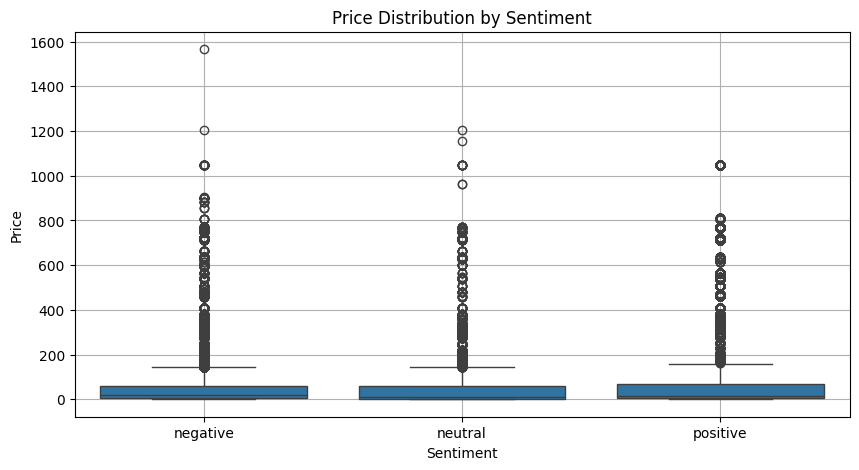

In [18]:
# Show summary statistics grouped by sentiment

print("Price summary by sentiment:")
print(df.groupby("sentiment", observed = False)["product_price"].describe())

# Boxplot of prices by sentiment

plt.figure(figsize=(10, 5))
sns.boxplot(data=df, x="sentiment", y="product_price")
plt.title("Price Distribution by Sentiment")
plt.xlabel("Sentiment")
plt.ylabel("Price")
plt.grid(True)
plt.show()


## Analiza: Duzina tekstualnog zapisa

Revies length summary:
count    165960.000000
mean         48.378435
std          76.611087
min           1.000000
25%           9.000000
50%          19.000000
75%          50.000000
max         523.000000
Name: review_length, dtype: float64
Review length statistic by sentiment
              count       mean        std  min   25%   50%   75%    max
sentiment                                                              
negative    44663.0  60.900701  78.376363  1.0  16.0  32.0  71.0  523.0
neutral     13678.0  41.418190  64.707990  1.0   7.0  19.0  47.0  500.0
positive   107619.0  44.066187  76.679684  1.0   8.0  15.0  41.0  497.0


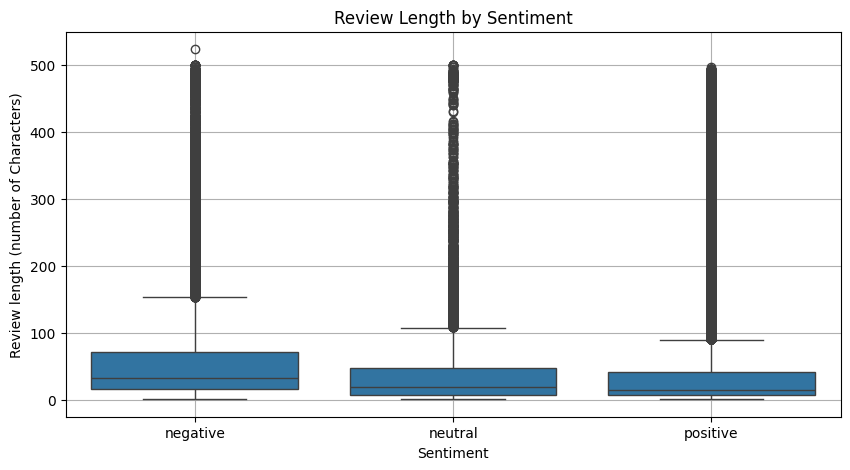

In [19]:
# Create new column with length of each review text
df["review_length"] = df["review_text"].astype(str).str.len()

# Show basic stats
print("Revies length summary:")
print(df["review_length"].describe())

# Group by sentiment and describe review length
print("Review length statistic by sentiment")
print(df.groupby("sentiment", observed=False)["review_length"].describe())

# Visualize distribution of review length by sentiment
plt.figure (figsize=(10, 5))
sns.boxplot(data=df, x="sentiment", y="review_length")
plt.title("Review Length by Sentiment")
plt.xlabel("Sentiment")
plt.ylabel("Review length (number of Characters)")
plt.grid(True)
plt.show()

## Training and Compairing Multiple Machine Learning Models

In [20]:
# Features and label

X = df[["review_title", "review_text", "review_length"]]
y = df["sentiment"]

In [21]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test= train_test_split(X, y, test_size = 0.2, random_state=42, stratify=y)


In [22]:
from sklearn.preprocessing import MinMaxScaler
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.feature_extraction.text import TfidfVectorizer

# Preprocesor : TF-IDF for text, MinMaxScaler for numeric feature

preprocesor = ColumnTransformer(
    transformers= [
        ("title", TfidfVectorizer(), "review_title"),
        ("text", TfidfVectorizer(), "review_text"),
        ("length", MinMaxScaler(), ["review_length"])

    ]
)

In [23]:
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import MultinomialNB
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import LinearSVC
from sklearn.metrics import classification_report

# list of Classifiers

models = {
    "Logistic Regression": LogisticRegression(max_iter=1000),
    "Naive Bayes": MultinomialNB(),
    "Decision Tree": DecisionTreeClassifier(),
    "Random Forest": RandomForestClassifier(),
    "Suport Vector Machine": LinearSVC()
}

# Train and evaluate

for name, model in models.items():
  print(f"\n {name}")
  pipeline = Pipeline([
      ("preprocessing", preprocesor),
      ("classifier", model)
  ])

  pipeline.fit(X_train, y_train)
  y_pred = pipeline.predict(X_test)
  print(classification_report(y_test, y_pred))


 Logistic Regression
              precision    recall  f1-score   support

    negative       0.88      0.92      0.90      8932
     neutral       0.73      0.54      0.62      2736
    positive       0.96      0.97      0.97     21524

    accuracy                           0.92     33192
   macro avg       0.86      0.81      0.83     33192
weighted avg       0.92      0.92      0.92     33192


 Naive Bayes
              precision    recall  f1-score   support

    negative       0.86      0.89      0.87      8932
     neutral       0.81      0.28      0.42      2736
    positive       0.92      0.98      0.95     21524

    accuracy                           0.90     33192
   macro avg       0.86      0.72      0.75     33192
weighted avg       0.89      0.90      0.88     33192


 Decision Tree
              precision    recall  f1-score   support

    negative       0.88      0.90      0.89      8932
     neutral       0.62      0.58      0.60      2736
    positive       0.96